In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, special

In [2]:
# ---------- Configuracion ----------
alpha = 0.05
# tamaño de muestra adecuado
N = 100_000
# parametros de la Normal
mu = 0.0
sigma = 1.0

### Muestras

In [3]:
# Teorica con scipy.stats
rng_np = np.random.default_rng(42)
theoretical = stats.norm.rvs(loc=mu, scale=sigma, size=N, random_state=42)

# Empirica con transformada integral: X = mu + sigma*sqrt(2)*erfinv(2U-1)
U = rng_np.random(N)
empirical = mu + sigma * np.sqrt(2.0) * special.erfinv(2.0*U - 1.0)


### Estadísticos descriptivos


In [4]:
def describe(x):
    return {
        "n": x.size,
        "media": float(np.mean(x)),
        "desv_est": float(np.std(x, ddof=1)),
        "min": float(np.min(x)),
        "q1": float(np.quantile(x, 0.25)),
        "mediana": float(np.median(x)),
        "q3": float(np.quantile(x, 0.75)),
        "max": float(np.max(x)),
    }

desc_theo = describe(theoretical)
desc_emp = describe(empirical)

print("\nEstadisticos descriptivos")
for k in desc_theo.keys():
    print(f"  {k:>9}: teorica={desc_theo[k]: .5f} | empirica={desc_emp[k]: .5f}")



Estadisticos descriptivos
          n: teorica= 100000.00000 | empirica= 100000.00000
      media: teorica= 0.00097 | empirica= 0.00149
   desv_est: teorica= 1.00091 | empirica= 1.00066
        min: teorica=-4.46560 | empirica=-4.20303
         q1: teorica=-0.67449 | empirica=-0.67298
    mediana: teorica= 0.00265 | empirica= 0.00617
         q3: teorica= 0.67691 | empirica= 0.67338
        max: teorica= 4.47908 | empirica= 4.36810


### Graficos

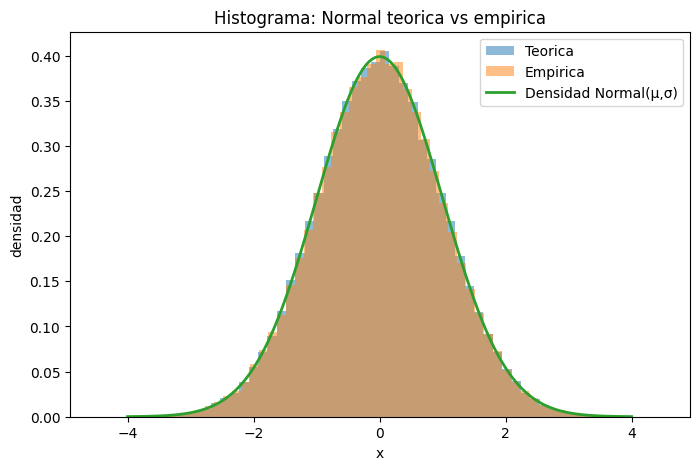

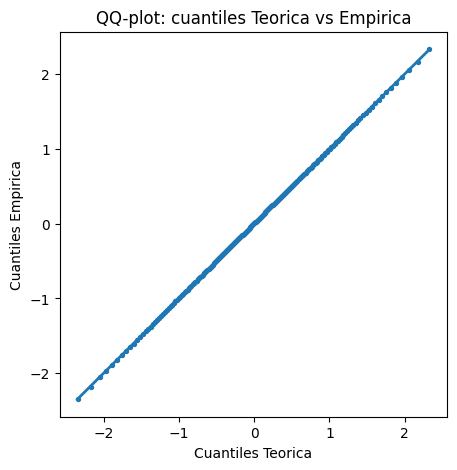

In [5]:
# Histograma comparativo
plt.figure(figsize=(8,5))
plt.hist(theoretical, bins=60, density=True, alpha=0.5, label="Teorica")
plt.hist(empirical,   bins=60, density=True, alpha=0.5, label="Empirica")
x = np.linspace(mu-4*sigma, mu+4*sigma, 400)
plt.plot(x, stats.norm.pdf(x, mu, sigma), linewidth=2, label="Densidad Normal(μ,σ)")
plt.title("Histograma: Normal teorica vs empirica")
plt.xlabel("x"); plt.ylabel("densidad"); plt.legend(); plt.show()

# QQ-plot (cuantiles)
q = np.linspace(0.01, 0.99, 199)
q_theo = np.quantile(theoretical, q)
q_emp  = np.quantile(empirical, q)
plt.figure(figsize=(5,5))
plt.scatter(q_theo, q_emp, s=8)
lims = [min(q_theo.min(), q_emp.min()), max(q_theo.max(), q_emp.max())]
plt.plot(lims, lims, linewidth=2)
plt.title("QQ-plot: cuantiles Teorica vs Empirica")
plt.xlabel("Cuantiles Teorica"); plt.ylabel("Cuantiles Empirica"); plt.show()